# Calorie Expenditure Prediction
**Model:** Simple & Multiple Linear Regression  
**Dataset:** 750,000 training rows, 250,000 test rows  
**Target:** Calories burned during exercise  
**Author:** Areeba Bushra

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/Calorie Expenditure.csv')
print(df.shape)
df.head()

(750000, 9)


,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


## 3. Exploratory Data Analysis (EDA)

In [5]:
# Basic statistics
print('== Info ==')
df.info()
print()
print('== Descriptive Statistics ==')
df.describe()

== Info ==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB

== Descriptive Statistics ==


,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,216506.495284,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,187499.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,374999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,562499.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,749999.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [6]:
# Missing values check
print('Missing values in training set:')
print(df.isnull().sum())
print()


Missing values in training set:
id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64



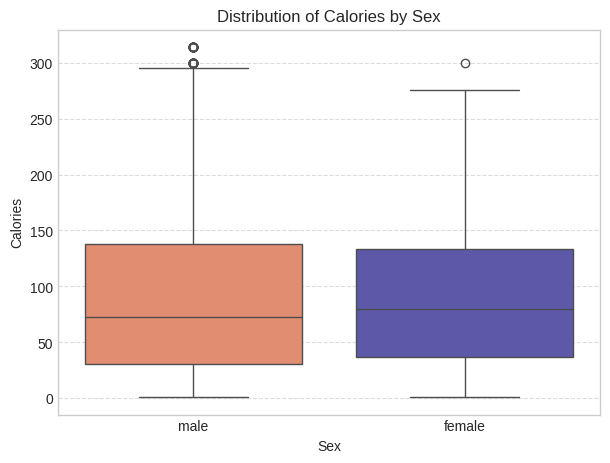

In [7]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Sex', y='Calories', data=df, palette=['#F4845F', '#534AB7'])
plt.title('Distribution of Calories by Sex')
plt.xlabel('Sex')
plt.ylabel('Calories')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [8]:
# Check how correlated each feature is with Calories
# We encode Sex first: male=1, female=0
df['Sex_enc'] = (df['Sex'] == 'male').astype(int)

features = ['Sex_enc', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

print('Correlation of each feature with Calories:')
print(df[features].corrwith(df['Calories']).sort_values(ascending=False))

Correlation of each feature with Calories:
Duration      0.959908
Heart_Rate    0.908748
Body_Temp     0.828671
Age           0.145683
Weight        0.015863
Sex_enc       0.012011
Height       -0.004026
dtype: float64


In [9]:
x = df[features]
y = df['Calories']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=3)

print(f'Training samples:   {x_train.shape[0]:,}')
print(f'Validation samples: {x_test.shape[0]:,}')

Training samples:   600,000
Validation samples: 150,000


In [10]:
# Test each feature one by one
print("Feature | R² | RMSE")


for i in features:
    model = LinearRegression()
    model.fit(x_train[[i]], y_train)          # train on one feature
    preds = model.predict(x_test[[i]])         # predict on validation set

    r2   = r2_score(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    print(f"{i} | {r2:.4f} | {rmse:.4f}")

Feature | R² | RMSE
Sex_enc | 0.0000 | 62.4206
Age | 0.0208 | 61.7707
Height | -0.0000 | 62.4223
Weight | 0.0002 | 62.4163
Duration | 0.9214 | 17.5007
Heart_Rate | 0.8265 | 26.0037
Body_Temp | 0.6876 | 34.8911


In [11]:
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [12]:
lr.score(x_test,y_test)

0.968459160217948

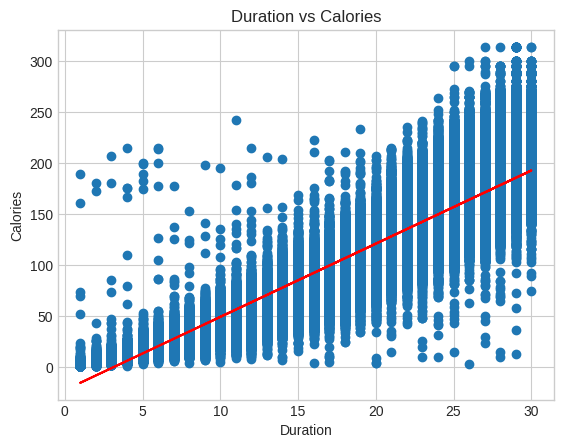

In [13]:

model = LinearRegression()
model.fit(x_train[['Duration']], y_train)

# Predict values for the training data
predictions = model.predict(x_train[['Duration']])

# Scatter plot
plt.scatter(x_train['Duration'], y_train)

# Regression line
plt.plot(x_train['Duration'], predictions, color='red')

plt.xlabel('Duration')
plt.ylabel('Calories')
plt.title('Duration vs Calories')

plt.show()

In [18]:


pred = model.predict(x_test[['Duration']])

# Check performance
r2 = r2_score(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
mae = mean_absolute_error(y_test, pred)

print(f"R²: {r2:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"MAE = {mae:.4f}")

R²: 0.9214
RMSE = 17.5007
MAE = 12.6789


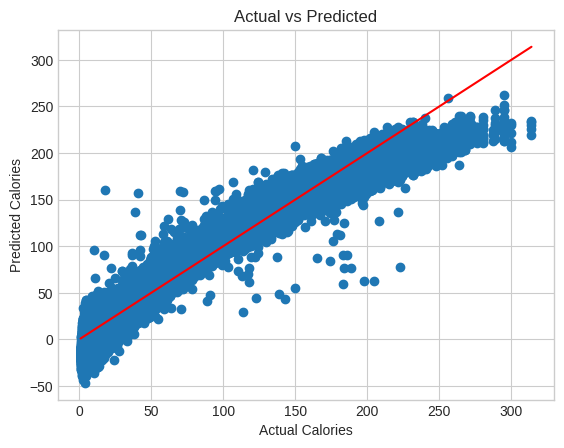

In [17]:

# Predict calories
y_pred = lr.predict(x_test)

# Plot actual vs predicted
plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted")

plt.show()

## 8. Key Findings & Limitations

### ✅ What worked well
- **R² = 0.968** — the model explains 96.8% of variance in calorie burn
- **Duration** is the single strongest predictor (simple R² = 0.922)
- **Heart Rate** and **Body Temp** add meaningful signal on top
- Large dataset (750K rows) means the model is very stable

### ⚠️ Limitations
- **Multicollinearity:** Duration, Heart Rate, and Body Temp rise together during exercise. The Body Temp coefficient appears negative despite a positive correlation — don't interpret individual coefficients literally
- **Negative predictions:** Linear regression has no domain constraints; some test predictions were clipped to 1
- **Missing non-linear patterns:** A higher R² could likely be achieved with polynomial features or tree-based models (Random Forest, XGBoost)
